В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

In [1]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import operator

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.preprocessing import PolynomialFeatures

Matplotlib is building the font cache; this may take a moment.


C:\Users\akore\AppData\Local\Temp\ipykernel_7876\2281377488.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train_inputs.select_dtypes(include='object').columns.tolist()


ROC-AUC on Train dataset: 0.8824


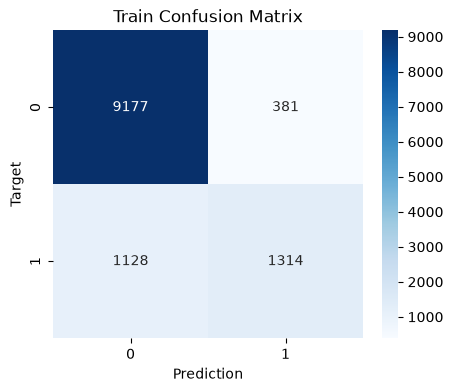

ROC-AUC on Validation dataset: 0.8797


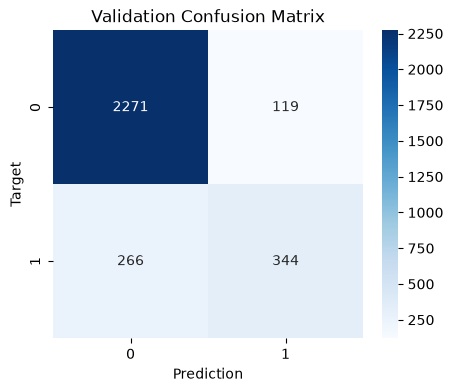

Model saved to: ../../Sample Data/bank-customer-churn-prediction-dlu-course-c-5/artifacts/log_reg_pipeline.joblib


In [2]:
raw_df = pd.read_csv(
    '../../Sample Data/bank-customer-churn-prediction-dlu-course-c-5/train.csv'
 )

train_df, val_df = train_test_split(
    raw_df,
    test_size=0.2,
    random_state=42,
    stratify=raw_df['Exited']
 )

# Створюємо трен. і вал. набори
drop_cols = ['Exited', 'id', 'CustomerId', 'Surname']
input_cols = [col for col in raw_df.columns if col not in drop_cols]
target_col = 'Exited'

train_inputs, train_targets = train_df[input_cols].copy(), train_df[target_col].copy()
val_inputs, val_targets = val_df[input_cols].copy(), val_df[target_col].copy()

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include='number').columns.tolist()
categorical_cols = train_inputs.select_dtypes(include='object').columns.tolist()

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Створюємо пайплайн, який спочатку запускає препроцесинг, потім тренує модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', max_iter=1000))
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    proba = model_pipeline.predict_proba(inputs)[:, 1]
    roc_auc = roc_auc_score(targets, proba)
    print(f'ROC-AUC on {name} dataset: {roc_auc:.4f}')

    confusion_matrix_ = confusion_matrix(targets, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix_, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title(f'{name} Confusion Matrix')
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, 'Validation')

# Зберігаємо модель для подальшого використання
artifacts_dir = '../../Sample Data/bank-customer-churn-prediction-dlu-course-c-5/artifacts'
os.makedirs(artifacts_dir, exist_ok=True)
joblib.dump(model_pipeline, f'{artifacts_dir}/log_reg_pipeline.joblib')
print('Model saved to:', f'{artifacts_dir}/log_reg_pipeline.joblib')

**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

ROC-AUC on Train Poly2 dataset: 0.9217


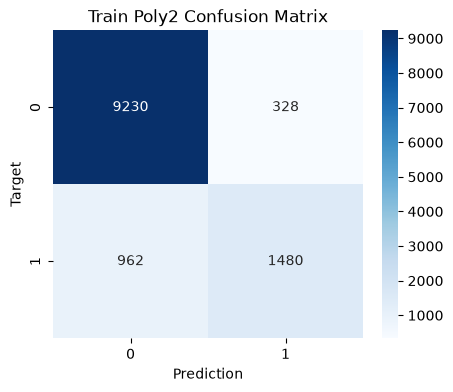

ROC-AUC on Validation Poly2 dataset: 0.9191


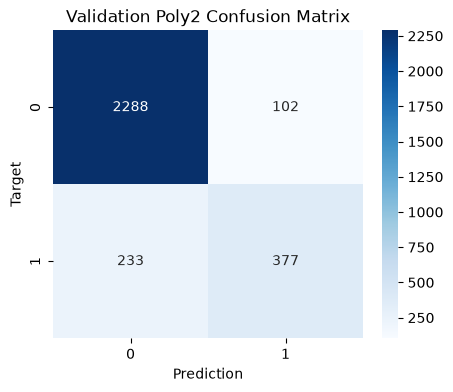

In [6]:
# Новий трансформер для числових ознак: масштабування + поліноміальні ознаки до степеня 2
numeric_transformer_poly2 = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False))
])

# Новий препроцесор
preprocessor_polynomial_2 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly2, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Новий пайплайн: препроцесинг + логістична регресія
model_pipeline_poly2 = Pipeline(steps=[
    ('preprocessor', preprocessor_polynomial_2),
    ('classifier', LogisticRegression(solver='liblinear', max_iter=2000))
])

# Тренуємо пайплайн
model_pipeline_poly2.fit(train_inputs, train_targets)

# Оцінюємо якість на train/validation
train_preds_poly2 = predict_and_plot(model_pipeline_poly2, train_inputs, train_targets, 'Train Poly2')
val_preds_poly2 = predict_and_plot(model_pipeline_poly2, val_inputs, val_targets, 'Validation Poly2')

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

ROC-AUC on Train Poly3 dataset: 0.9330


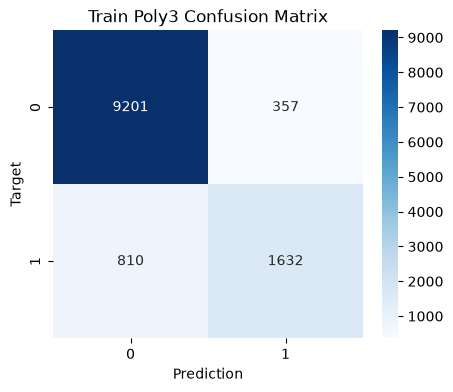

ROC-AUC on Validation Poly3 dataset: 0.9301


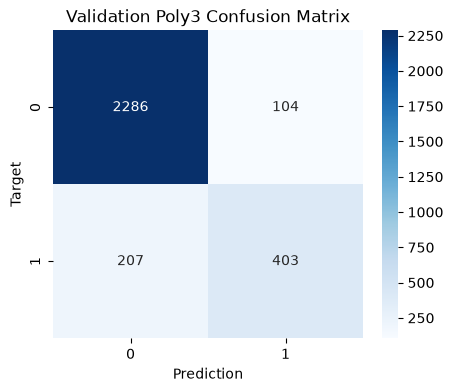

In [15]:
# Новий трансформер для числових ознак: масштабування + поліноміальні ознаки до степеня 2
numeric_transformer_poly3 = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly', PolynomialFeatures(degree=4, include_bias=False))
])

# Новий препроцесор
preprocessor_polynomial_3 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly3, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Новий пайплайн: препроцесинг + логістична регресія
model_pipeline_poly3 = Pipeline(steps=[
    ('preprocessor', preprocessor_polynomial_3),
    ('classifier', LogisticRegression(solver='liblinear', max_iter=2000))
])

# Тренуємо пайплайн
model_pipeline_poly3.fit(train_inputs, train_targets)

# Оцінюємо якість на train/validation
train_preds_poly3 = predict_and_plot(model_pipeline_poly3, train_inputs, train_targets, 'Train Poly3')
val_preds_poly3 = predict_and_plot(model_pipeline_poly3, val_inputs, val_targets, 'Validation Poly3')

In [9]:
test_raw_df = pd.read_csv('../../Sample Data/bank-customer-churn-prediction-dlu-course-c-5/test.csv')

In [ ]:
test_raw_df['Exited'] = model_pipeline_poly3.predict_proba(test_raw_df[input_cols])[:, 1]
display(test_raw_df[['id', 'Exited']].head())

,id,Exited
0,15000,0.078725
1,15001,0.020312
2,15002,0.070261
3,15003,0.397865
4,15004,0.025534


In [26]:
sample_submission_file = pd.read_csv(
    '../../Sample Data/bank-customer-churn-prediction-dlu-course-c-5/sample_submission.csv'
 )

sample_submission_df = sample_submission_file.drop(columns=['Exited']).merge(
    test_raw_df[['id', 'Exited']],
    on='id',
    how='left'
 )

display(sample_submission_df.head())

sample_submission_df.to_csv(
    '../../Sample Data/bank-customer-churn-prediction-dlu-course-c-5/submission_file_2.csv',
    index=False
)

,id,Exited
0,15000,0.078725
1,15001,0.020312
2,15002,0.070261
3,15003,0.397865
4,15004,0.025534


**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [27]:
regression_data_raw_df = pd.read_csv('../../Sample Data/regression_data.csv')
regression_data_raw_df

,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,-0.190339,-1.382800,-0.875618,0.538910,-1.037246,28.938854
1,-0.321386,-0.563725,0.412931,-0.147057,-0.825497,-7.664581
2,2.122156,-1.519370,1.032465,-1.260884,0.917862,-63.845482
3,-1.380101,-0.055548,-1.703382,0.074095,1.628616,4.076259
4,-0.072829,-1.514847,-0.846794,0.714000,0.473238,34.879013
...,...,...,...,...,...,...
124,1.402794,0.586857,-1.401851,0.791032,-0.909387,39.626185
125,-0.288659,-0.827231,0.322719,-1.002529,-0.018513,-50.585687
126,-1.407464,-0.213447,-0.718444,0.232050,-1.448084,13.719861
127,1.353872,1.237816,-0.114540,-0.469176,-1.713135,-23.851350


In [29]:
train_df, test_df = train_test_split(
    regression_data_raw_df,
    test_size=0.2,
    random_state=42
)

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Виділяємо ознаки та таргет для регресії
target_col_reg = 'target'
feature_cols_reg = [col for col in regression_data_raw_df.columns if col != target_col_reg]

X_train_reg = train_df[feature_cols_reg].copy()
y_train_reg = train_df[target_col_reg].copy()
X_test_reg = test_df[feature_cols_reg].copy()
y_test_reg = test_df[target_col_reg].copy()

numeric_cols_reg = X_train_reg.select_dtypes(include='number').columns.tolist()
categorical_cols_reg = X_train_reg.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

numeric_transformer_reg_5 = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly', PolynomialFeatures(degree=5, include_bias=False))
])

categorical_transformer_reg = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_reg_5 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_reg_5, numeric_cols_reg),
        ('cat', categorical_transformer_reg, categorical_cols_reg)
    ]
)

linreg_poly5_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_reg_5),
    ('regressor', LinearRegression())
])

linreg_poly5_pipeline.fit(X_train_reg, y_train_reg)

train_pred_reg5 = linreg_poly5_pipeline.predict(X_train_reg)
test_pred_reg5 = linreg_poly5_pipeline.predict(X_test_reg)

train_rmse_reg5 = mean_squared_error(y_train_reg, train_pred_reg5) ** 0.5
test_rmse_reg5 = mean_squared_error(y_test_reg, test_pred_reg5) ** 0.5
train_mae_reg5 = mean_absolute_error(y_train_reg, train_pred_reg5)
test_mae_reg5 = mean_absolute_error(y_test_reg, test_pred_reg5)
train_r2_reg5 = r2_score(y_train_reg, train_pred_reg5)
test_r2_reg5 = r2_score(y_test_reg, test_pred_reg5)

print('Task 4 - LinearRegression + PolynomialFeatures(degree=5)')
print(f'Train RMSE: {train_rmse_reg5:.4f}')
print(f'Test  RMSE: {test_rmse_reg5:.4f}')
print(f'Train MAE : {train_mae_reg5:.4f}')
print(f'Test  MAE : {test_mae_reg5:.4f}')
print(f'Train R2  : {train_r2_reg5:.4f}')
print(f'Test  R2  : {test_r2_reg5:.4f}')

if train_r2_reg5 - test_r2_reg5 > 0.15:
    print('Висновок: є ознаки перенавчання (overfitting).')
elif test_r2_reg5 < 0.3:
    print('Висновок: модель слабко узагальнює (можливий underfitting).')
else:
    print('Висновок: модель узагальнює задовільно.')

Task 4 - LinearRegression + PolynomialFeatures(degree=5)
Train RMSE: 0.0000
Test  RMSE: 17.3488
Train MAE : 0.0000
Test  MAE : 10.8340
Train R2  : 1.0000
Test  R2  : 0.8710
Висновок: модель узагальнює задовільно.


**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [ ]:
from sklearn.linear_model import Lasso, Ridge, ElasticNet

# Поліноміальні ознаки до степеня 20
numeric_transformer_reg_20 = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly', PolynomialFeatures(degree=20, include_bias=False))
])

preprocessor_reg_20 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_reg_20, numeric_cols_reg),
        ('cat', categorical_transformer_reg, categorical_cols_reg)
    ]
)

models = {
    'LinearRegression': LinearRegression(),
    'Lasso': Lasso(alpha=0.001, max_iter=20000, random_state=42),
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'ElasticNet': ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=20000, random_state=42)
}

results = []

for model_name, reg_model in models.items():
    model_pipeline_reg = Pipeline(steps=[
        ('preprocessor', preprocessor_reg_20),
        ('regressor', reg_model)
    ])
    model_pipeline_reg.fit(X_train_reg, y_train_reg)

    train_pred = model_pipeline_reg.predict(X_train_reg)
    test_pred = model_pipeline_reg.predict(X_test_reg)

    train_rmse = mean_squared_error(y_train_reg, train_pred) ** 0.5
    test_rmse = mean_squared_error(y_test_reg, test_pred) ** 0.5
    train_r2 = r2_score(y_train_reg, train_pred)
    test_r2 = r2_score(y_test_reg, test_pred)

    results.append({
        'model': model_name,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'r2_gap': train_r2 - test_r2
    })

results_df = pd.DataFrame(results).sort_values(by='test_r2', ascending=False)
display(results_df)

best_model_row = results_df.iloc[0]
print(f"Найкраща модель за test_r2: {best_model_row['model']}")
print(f"test_r2: {best_model_row['test_r2']:.4f}")

,model,train_rmse,test_rmse,train_r2,test_r2,r2_gap
1,Lasso,9.261754e-01,1.038873,0.999560,0.999537,0.000022
3,ElasticNet,1.603625e+00,1.748311,0.998680,0.998690,-0.000010
2,Ridge,5.885065e+00,7.021050,0.982219,0.978871,0.003348
0,LinearRegression,7.602179e-13,12.734214,1.000000,0.930495,0.069505


Найкраща модель за test_r2: Lasso
Її test_r2: 0.9995
Висновок: регуляризовані моделі (Ridge/Lasso/ElasticNet) зазвичай краще генералізують на високих степенях полінома,
бо штрафують надто великі коефіцієнти і зменшують перенавчання порівняно з базовою LinearRegression.


Висновок: регуляризовані моделі (Ridge/Lasso/ElasticNet) краще генералізують на високих степенях полінома порівняно з базовою LinearRegression.